In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connexion à la base
conn = sqlite3.connect('../dev/input/olist.db')


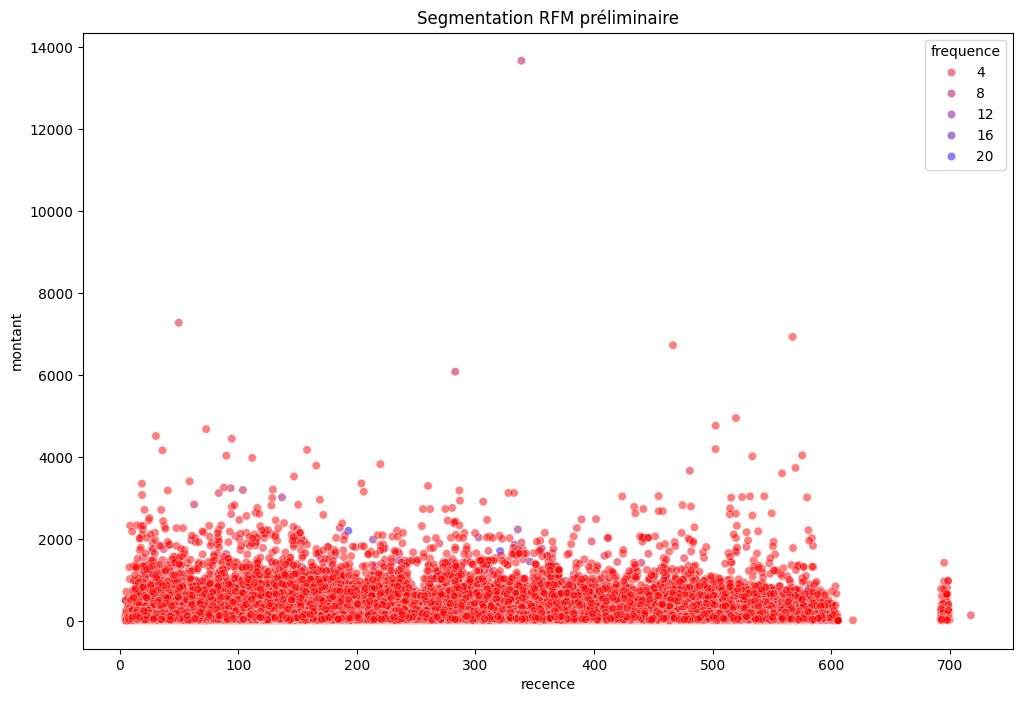

In [ ]:
rfm_query = """
WITH from_now AS (
    SELECT 
        MAX(order_purchase_timestamp) AS max_timestamp 
    FROM orders o WHERE o.order_status != "canceled"
) 
select  JULIANDAY(n.max_timestamp) - JULIANDAY(o.order_purchase_timestamp) AS recence,
		COUNT(o.order_id) AS frequence,
		oi.price, oi.freight_value, sum(oi.price + oi.freight_value) as montant 
    FROM orders o
    CROSS JOIN from_now n
    INNER JOIN order_items oi ON o.order_id = oi.order_id
    INNER JOIN customers c ON o.customer_id = c.customer_id 
    INNER JOIN order_reviews rev ON o.order_id = rev.order_id
    INNER JOIN sellers s ON oi.seller_id = s.seller_id
    WHERE o.order_status = 'delivered'
    GROUP BY o.customer_id
    ORDER BY frequence DESC
"""
rfm_df = pd.read_sql(rfm_query, conn)

# Créer une palette personnalisée allant du bleu au rouge
colors = ["red", "blue"]
custom_palette = sns.blend_palette(colors, as_cmap=True)

# Définir la taille de la figure
plt.figure(figsize=(12, 8))  # Largeur de 12 pouces et hauteur de 8 pouces

# Matrice RFM
sns.scatterplot(df_no_outliers=rfm_df, x='recence', y='montant', hue='frequence', palette=custom_palette, alpha=0.5)
plt.title('Segmentation RFM préliminaire')
plt.show()

In [3]:
# Nettoyage des valeurs négatives/incohérentes
rfm_df = rfm_df[rfm_df['recence'] >= 0]

# Segmentation par quantiles
def rfm_quantile_segmentation(df):
    df['R_Score'] = pd.qcut(df['recence'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
    # Ajustement pour frequence et montant si nécessaire
    try:
        df['F_Score'] = pd.qcut(df['frequence'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)
    except ValueError:
        df['F_Score'] = pd.cut(df['frequence'], bins=5, labels=[1,2,3,4,5], include_lowest=True).astype(int)
    try:
        df['M_Score'] = pd.qcut(df['montant'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)
    except ValueError:
        df['M_Score'] = pd.cut(df['montant'], bins=5, labels=[1,2,3,4,5], include_lowest=True).astype(int)
    df['RFM_Score'] = df['R_Score'].astype(str) + df['F_Score'].astype(str) + df['M_Score'].astype(str)
    return df

# Application
rfm_scored = rfm_quantile_segmentation(rfm_df)

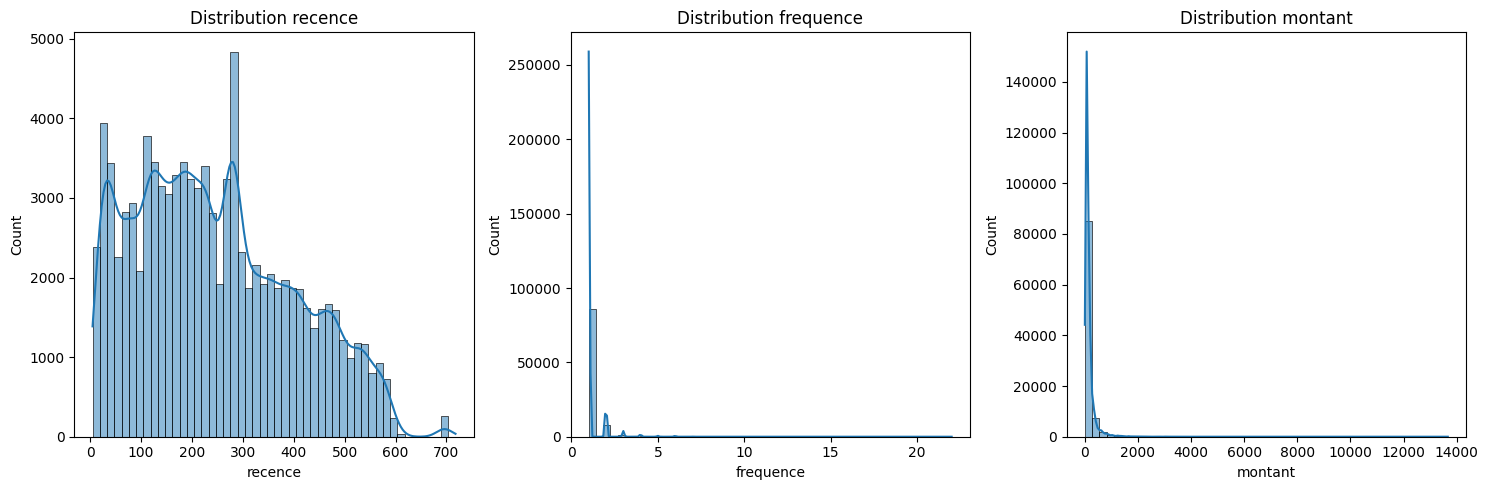

In [4]:
# Visualisation des distributions
plt.figure(figsize=(15, 5))
for i, col in enumerate(['recence', 'frequence', 'montant'], 1):
    plt.subplot(1, 3, i)
    sns.histplot(rfm_scored[col], bins=50, kde=True)
    plt.title(f'Distribution {col}')
plt.tight_layout()
plt.show()

In [ ]:
def segment_rfm(rfm_score):
    if rfm_score == '555':
        return 'Champions'
    elif rfm_score.startswith('5'):
        return 'Loyaux'
    elif rfm_score.endswith('5'):
        return 'A réactiver'
    elif '4' in rfm_score:
        return 'Loyalistes Potentiels'
    elif '3' in rfm_score:
        return 'Besoin Attention'
    elif '2' in rfm_score:
        return 'A risque'
    elif '1' in rfm_score:
        return 'Perdus'
    else:
        return 'About to Sleep'

# Appliquer la fonction de segmentation
# rfm['segment'] = rfm['rfm_score'].apply(segment_rfm)
rfm_scored["segment"] = rfm_scored["RFM_Score"].apply(segment_rfm)

# Afficher le df_no_outliersFrame RFM avec les segments
# print(rfm.head())
print(rfm_scored.head())


      recence  frequence   price  freight_value  montant  R_Score  F_Score  \
0  320.833657         22   69.90          33.72  1707.88        2        5   
1  413.616343         21    1.20           7.89   196.17        1        5   
2  192.733519         20  100.00          10.12  2202.40        3        5   
3  580.473704         15   51.00           1.20   783.00        1        4   
4  283.525058         15   65.49          16.22  1225.65        2        4   

   M_Score RFM_Score                segment  
0        5       255            A réactiver  
1        4       154  Loyalistes Potentiels  
2        5       355            A réactiver  
3        5       145            A réactiver  
4        5       245            A réactiver  


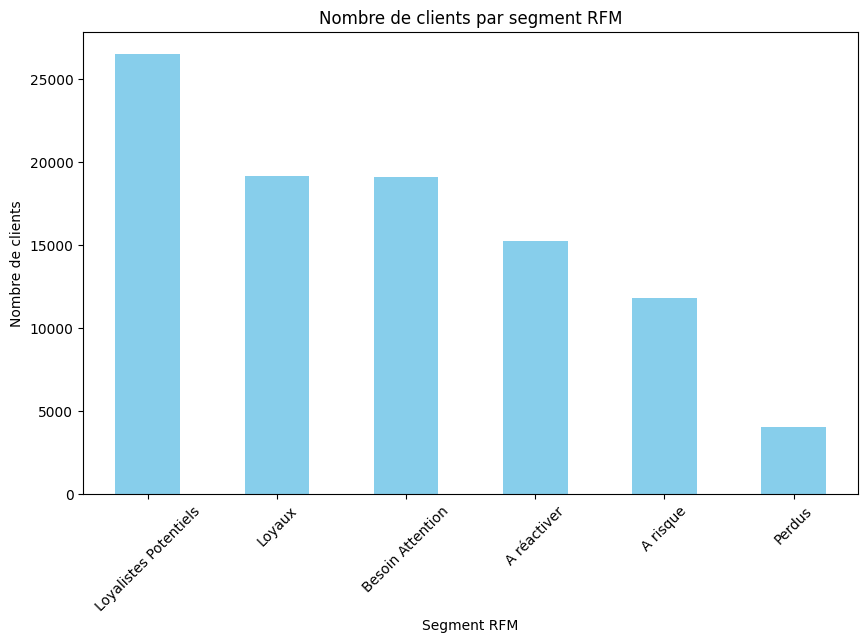

In [6]:
import matplotlib.pyplot as plt

# Compter le nombre de clients dans chaque segment
segment_counts = rfm_scored['segment'].value_counts()

# Créer un graphique en barres
plt.figure(figsize=(10, 6))
segment_counts.plot(kind='bar', color='skyblue')
plt.title('Nombre de clients par segment RFM')
plt.xlabel('Segment RFM')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=45)
plt.show()

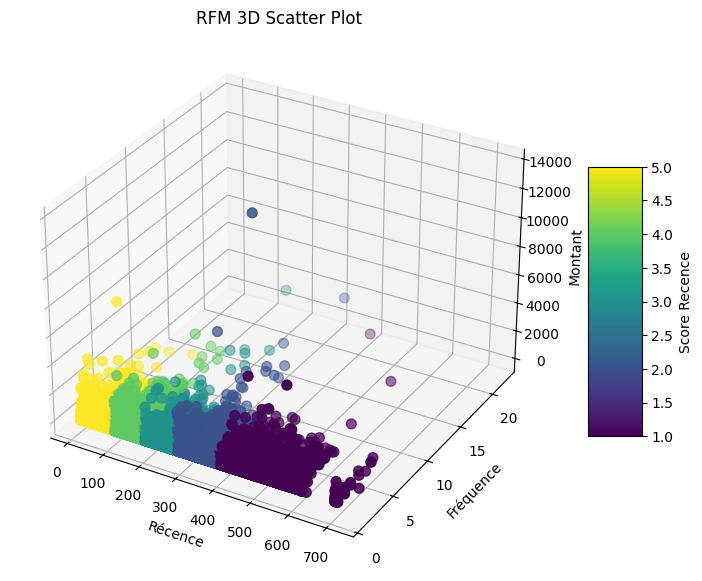

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Créer une figure et un axe 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Tracer les données RFM en 3D
scatter = ax.scatter(
    rfm_scored['recence'],
    rfm_scored['frequence'],
    rfm_scored['montant'],
    c=rfm_scored['R_Score'].astype(int),  # Couleur basée sur le score de récence
    cmap='viridis',
    s=50
)

# Ajouter des labels et un titre
ax.set_xlabel('Récence')
ax.set_ylabel('Fréquence')
ax.set_zlabel('Montant')
ax.set_title('RFM 3D Scatter Plot')

# Ajouter une barre de couleur
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)
cbar.set_label('Score Recence')

# Afficher le graphique
plt.show()

In [8]:
rfm_scored.describe()

,recence,frequence,price,freight_value,montant,R_Score,F_Score,M_Score
count,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000
mean,244.250395,1.147978,124.805109,20.105831,160.293483,3.000000,1.003078,2.999833
std,152.863661,0.550717,188.431754,15.764691,218.335925,1.414236,0.063965,1.414309
min,4.754398,1.000000,0.850000,0.000000,9.590000,1.000000,1.000000,1.000000
25%,120.358397,1.000000,40.800000,13.230000,62.010000,2.000000,1.000000,2.000000
50%,225.392147,1.000000,79.000000,16.330000,105.380000,3.000000,1.000000,3.000000
75%,353.946305,1.000000,139.612500,21.180000,176.880000,4.000000,1.000000,4.000000
max,717.868275,22.000000,6735.000000,409.680000,13664.080000,5.000000,5.000000,5.000000


## Clustering K-Means

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Sélectionner les caractéristiques pour le clustering
features = rfm_scored[['recence', 'frequence', 'montant']]

# Normaliser les données
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Appliquer l'algorithme K-means
kmeans = KMeans(n_clusters=5, random_state=42)
rfm_scored['cluster'] = kmeans.fit_predict(features_scaled)

# Afficher les résultats
print(rfm_scored.head())


      recence  frequence   price  freight_value  montant  R_Score  F_Score  \
0  320.833657         22   69.90          33.72  1707.88        2        5   
1  413.616343         21    1.20           7.89   196.17        1        5   
2  192.733519         20  100.00          10.12  2202.40        3        5   
3  580.473704         15   51.00           1.20   783.00        1        4   
4  283.525058         15   65.49          16.22  1225.65        2        4   

   M_Score RFM_Score                segment  cluster  
0        5       255            A réactiver        2  
1        4       154  Loyalistes Potentiels        2  
2        5       355            A réactiver        2  
3        5       145            A réactiver        2  
4        5       245            A réactiver        2  


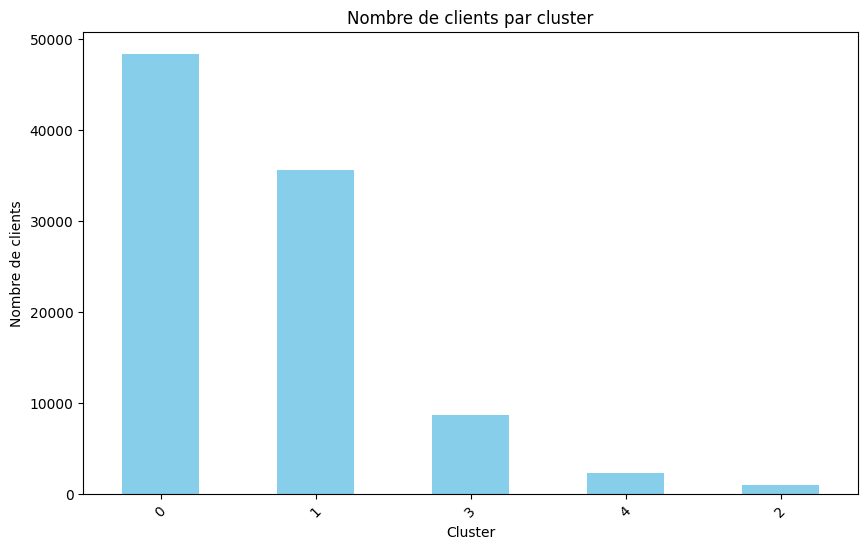

In [10]:
cluster_count = rfm_scored['cluster'].value_counts()

# Créer un graphique en barres
plt.figure(figsize=(10, 6))
cluster_count.plot(kind='bar', color='skyblue')
plt.title('Nombre de clients par cluster')
plt.xlabel('Cluster')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=45)
plt.show()

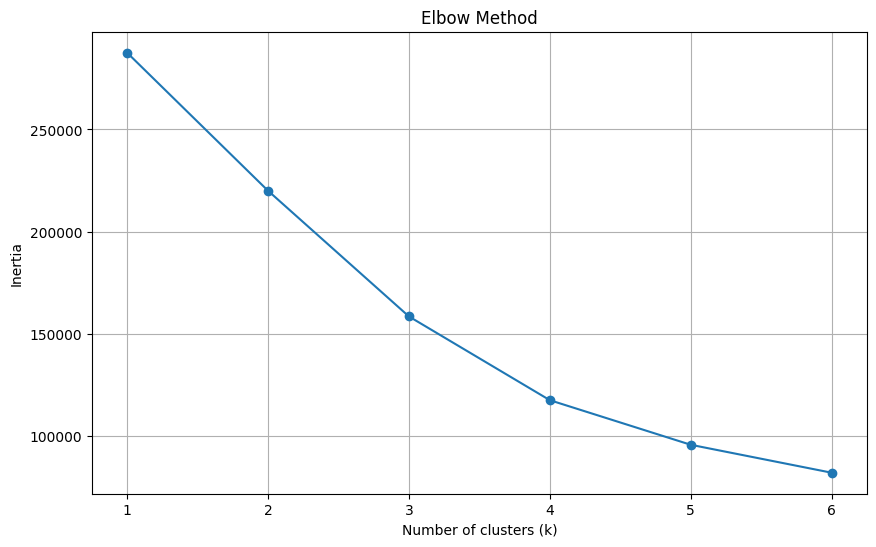

In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# Sélectionner les caractéristiques pour le clustering
features = rfm_scored[['recence', 'frequence', 'montant']]

# Normaliser les données
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Calculer l'inertie pour différentes valeurs de k
inertias = []
k_values = range(1, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)

# Tracer la méthode du coude
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid()
plt.show()

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Sélectionner les caractéristiques pour le clustering
features = rfm_scored[['recence', 'frequence', 'montant']]

# Normaliser les données
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Appliquer l'algorithme K-means
kmeans = KMeans(n_clusters=3, random_state=42)
rfm_scored['cluster'] = kmeans.fit_predict(features_scaled)

# Afficher les résultats
print(rfm_scored.head())

      recence  frequence   price  freight_value  montant  R_Score  F_Score  \
0  320.833657         22   69.90          33.72  1707.88        2        5   
1  413.616343         21    1.20           7.89   196.17        1        5   
2  192.733519         20  100.00          10.12  2202.40        3        5   
3  580.473704         15   51.00           1.20   783.00        1        4   
4  283.525058         15   65.49          16.22  1225.65        2        4   

   M_Score RFM_Score                segment  cluster  
0        5       255            A réactiver        2  
1        4       154  Loyalistes Potentiels        2  
2        5       355            A réactiver        2  
3        5       145            A réactiver        2  
4        5       245            A réactiver        2  


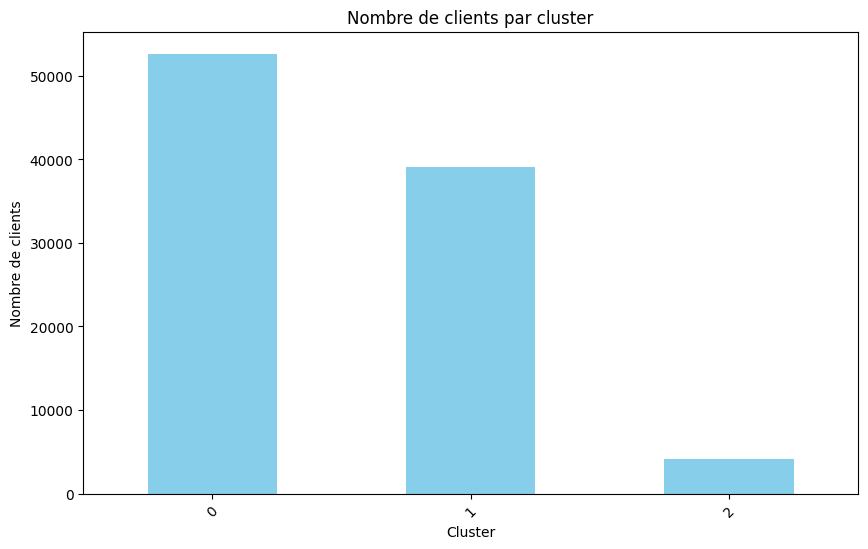

In [13]:
cluster_count = rfm_scored['cluster'].value_counts()

# Créer un graphique en barres
plt.figure(figsize=(10, 6))
cluster_count.plot(kind='bar', color='skyblue')
plt.title('Nombre de clients par cluster')
plt.xlabel('Cluster')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=45)
plt.show()

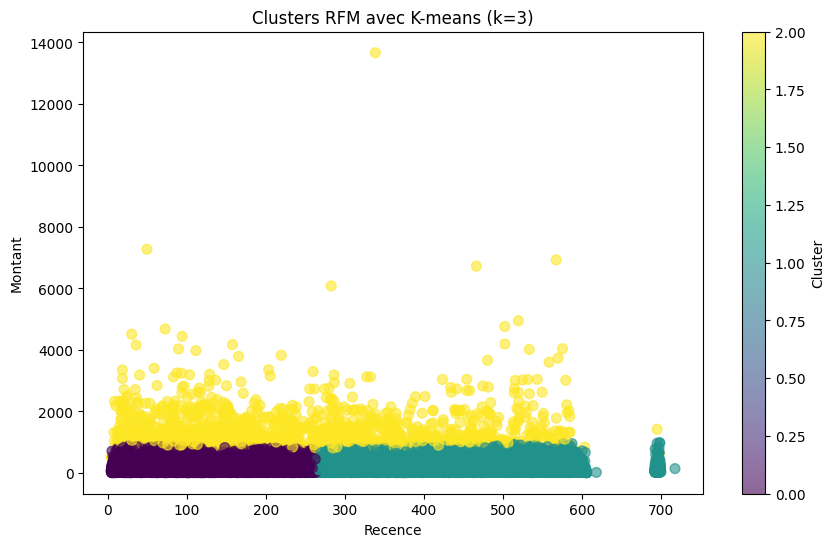

In [14]:
# Tracer les clusters
plt.figure(figsize=(10, 6))
plt.scatter(rfm_scored['recence'], rfm_scored['montant'], c=rfm_scored['cluster'], cmap='viridis', s=50, alpha=0.6)
plt.xlabel('Recence')
plt.ylabel('Montant')
plt.title('Clusters RFM avec K-means (k=3)')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
# Obtenir les centroïdes
centroids = kmeans.cluster_centers_

# Convertir les centroïdes en df_no_outliersFrame pour une meilleure visualisation
centroids_df = pd.df_no_outliersFrame(centroids, columns=['recence', 'frequence', 'montant'])

# Afficher les centroïdes
print(centroids_df)

    recence  frequence   montant
0 -0.723430  -0.133804 -0.115100
1  0.977251  -0.122281 -0.116055
2 -0.025069   2.876517  2.577741


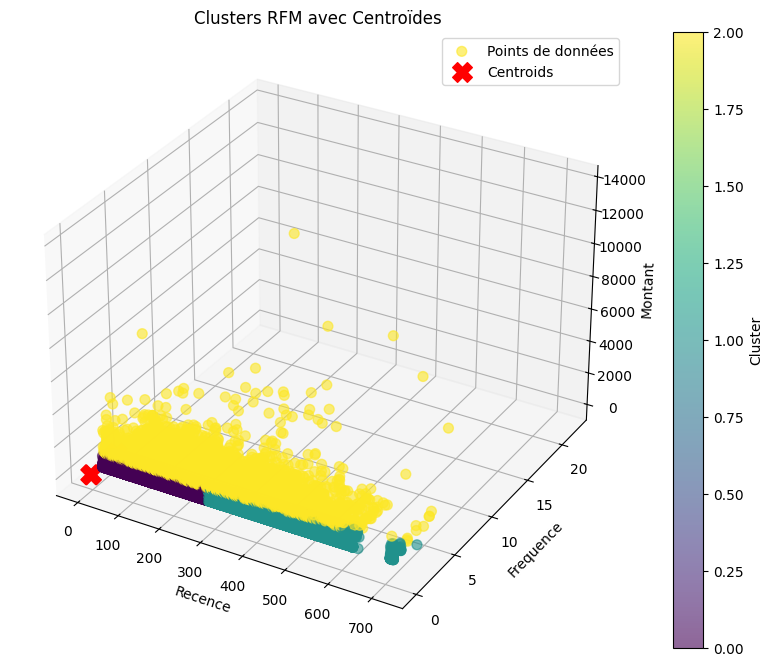

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

# Supposons que rfm_scored est votre df_no_outliersFrame et que vous avez déjà calculé les clusters
# features_scaled est votre ensemble de données normalisées
# kmeans est votre modèle KMeans ajusté

# Tracer les points de données
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Tracer les points de données colorés par cluster
scatter = ax.scatter(
    rfm_scored['recence'],
    rfm_scored['frequence'],
    rfm_scored['montant'],
    c=rfm_scored['cluster'],
    cmap='viridis',
    s=50,
    alpha=0.6,
    label='Points de données'
)

# Tracer les centroïdes
centroids = kmeans.cluster_centers_
ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    centroids[:, 2],
    c='red',
    s=200,
    alpha=1,
    marker='X',
    label='Centroids'
)

# Ajouter des labels et un titre
ax.set_xlabel('Recence')
ax.set_ylabel('Frequence')
ax.set_zlabel('Montant')
ax.set_title('Clusters RFM avec Centroïdes')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.legend()
plt.show()


## Clustering élargi

In [17]:
import sqlite3
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Connexion à la base
conn = sqlite3.connect('../dev/input/olist.db')

query = """
WITH from_now AS (
    SELECT 
        MAX(order_purchase_timestamp) AS max_timestamp 
    FROM orders o WHERE o.order_status != "canceled"
) 
select  JULIANDAY(n.max_timestamp) - JULIANDAY(o.order_purchase_timestamp) AS recence,
		COUNT(o.order_id) AS frequence,
		oi.price, oi.freight_value, sum(oi.price + oi.freight_value) as montant, rev.review_score, 
    order_purchase_timestamp, order_approved_at, order_delivered_customer_date
    FROM orders o
    CROSS JOIN from_now n
    INNER JOIN order_items oi ON o.order_id = oi.order_id
    INNER JOIN customers c ON o.customer_id = c.customer_id 
    INNER JOIN order_reviews rev ON o.order_id = rev.order_id
    INNER JOIN sellers s ON oi.seller_id = s.seller_id
    WHERE o.order_status = 'delivered'
    GROUP BY o.customer_id
    ORDER BY frequence DESC

    """

df = pd.read_sql(query, conn)

In [18]:
df.dtypes

recence                          float64
frequence                          int64
price                            float64
freight_value                    float64
montant                          float64
review_score                       int64
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_customer_date     object
dtype: object

In [19]:
from scipy import stats
import numpy as np

def detect_outliers_zscore(df, column, threshold=3):
    z_scores = np.abs(stats.zscore(df[column]))
    outliers = df[z_scores > threshold]
    return outliers

# Application
numeric_df = df.select_dtypes(include=[np.number])


# Application sur les colonnes numériques uniquement
for column in numeric_df.columns:
    outliers_zscore = detect_outliers_zscore(df, column)
    print(f"Colonne {column} - Outliers Z-score : {len(outliers_zscore)} clients")


Colonne recence - Outliers Z-score : 1 clients
Colonne frequence - Outliers Z-score : 2266 clients
Colonne price - Outliers Z-score : 1692 clients
Colonne freight_value - Outliers Z-score : 1758 clients
Colonne montant - Outliers Z-score : 1703 clients
Colonne review_score - Outliers Z-score : 0 clients


In [20]:
# Détecter les outliers pour les colonnes 'price' et 'freight_value'
outliers_price = detect_outliers_zscore(df, 'price')
outliers_freight = detect_outliers_zscore(df, 'freight_value')

# Combiner les indices des outliers des deux colonnes
outlier_indices = outliers_price.index.union(outliers_freight.index)

# Ensemble de données sans outliers
df_no_outliers = df.drop(outlier_indices)

In [21]:
df_no_outliers['order_purchase_timestamp'] = pd.to_datetime(df_no_outliers['order_purchase_timestamp'])
df_no_outliers['order_approved_at'] = pd.to_datetime(df_no_outliers['order_approved_at'])
df_no_outliers['order_delivered_customer_date'] = pd.to_datetime(df_no_outliers['order_delivered_customer_date'])


# Calcul du délai de validation (en minutes, heures ou jours selon la granularité souhaitée)
df_no_outliers['approval_delay_minutes'] = (df_no_outliers['order_approved_at'] - df_no_outliers['order_purchase_timestamp']).dt.total_seconds() / 60
df_no_outliers['approval_delay_hours'] = df_no_outliers['approval_delay_minutes'] / 60
df_no_outliers['approval_delay_days'] = (df_no_outliers['order_approved_at'] - df_no_outliers['order_purchase_timestamp']).dt.days

# En heures (optionnel)
df_no_outliers['processing_delay_hours'] = (df_no_outliers['order_delivered_customer_date'] - df_no_outliers['order_purchase_timestamp']).dt.total_seconds() / 3600


df_no_outliers['processing_delay_days'] = (df_no_outliers['order_delivered_customer_date'] - df_no_outliers['order_purchase_timestamp']).dt.days

In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Sélectionner les caractéristiques pour le clustering
features = df_no_outliers[['recence', 'frequence', 'montant']]

# Normaliser les données
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Appliquer l'algorithme K-means
kmeans = KMeans(n_clusters=3, random_state=42)
df_no_outliers['cluster'] = kmeans.fit_predict(features_scaled)

# Afficher les résultats
display(df_no_outliers.head())

,recence,frequence,price,freight_value,montant,review_score,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,approval_delay_minutes,approval_delay_hours,approval_delay_days,processing_delay_hours,processing_delay_days,cluster
0,320.833657,22,69.90,33.72,1707.88,1,2017-10-17 13:06:29,2017-10-18 13:06:21,2017-10-22 14:43:54,1439.866667,23.997778,0.0,121.623611,5.0,2
1,413.616343,21,1.20,7.89,196.17,1,2017-07-16 18:19:25,2017-07-17 18:25:23,2017-07-31 18:03:02,1445.966667,24.099444,1.0,359.726944,14.0,2
2,192.733519,20,100.00,10.12,2202.40,1,2018-02-22 15:30:41,2018-02-24 03:20:27,2018-03-05 15:22:27,2149.766667,35.829444,1.0,263.862778,10.0,2
3,580.473704,15,51.00,1.20,783.00,5,2017-01-30 21:44:49,2017-01-30 22:33:45,2017-02-14 10:48:10,48.933333,0.815556,0.0,349.055833,14.0,2
4,283.525058,15,65.49,16.22,1225.65,5,2017-11-23 20:30:52,2017-11-24 10:31:10,2017-12-13 20:19:35,840.300000,14.005000,0.0,479.811944,19.0,2


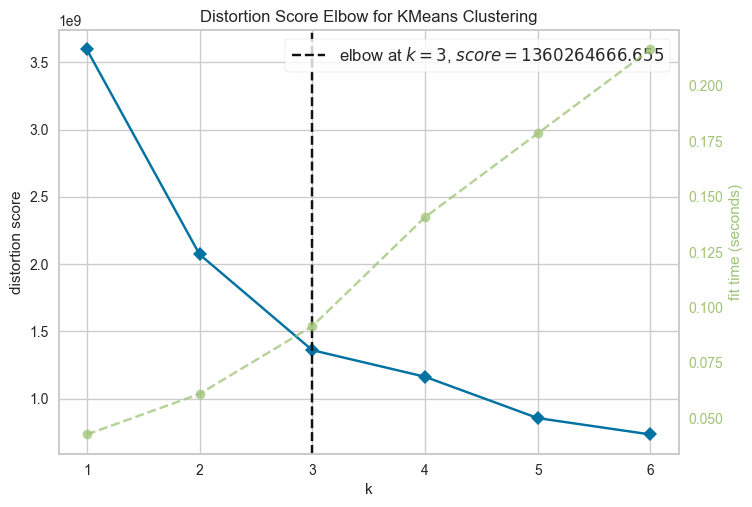

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:

from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
visualizer = KElbowVisualizer(kmeans, k=(1,7))

visualizer.fit(features)    # Fit the df_no_outliers to the visualizer
visualizer.poof()    # Draw/show/poof the df_no_outliers

In [24]:
numeric_df = df_no_outliers.select_dtypes(include=[np.number])
numeric_df.shape

(92773, 12)

In [25]:
display(numeric_df.head())

,recence,frequence,price,freight_value,montant,review_score,approval_delay_minutes,approval_delay_hours,approval_delay_days,processing_delay_hours,processing_delay_days,cluster
0,320.833657,22,69.90,33.72,1707.88,1,1439.866667,23.997778,0.0,121.623611,5.0,2
1,413.616343,21,1.20,7.89,196.17,1,1445.966667,24.099444,1.0,359.726944,14.0,2
2,192.733519,20,100.00,10.12,2202.40,1,2149.766667,35.829444,1.0,263.862778,10.0,2
3,580.473704,15,51.00,1.20,783.00,5,48.933333,0.815556,0.0,349.055833,14.0,2
4,283.525058,15,65.49,16.22,1225.65,5,840.300000,14.005000,0.0,479.811944,19.0,2


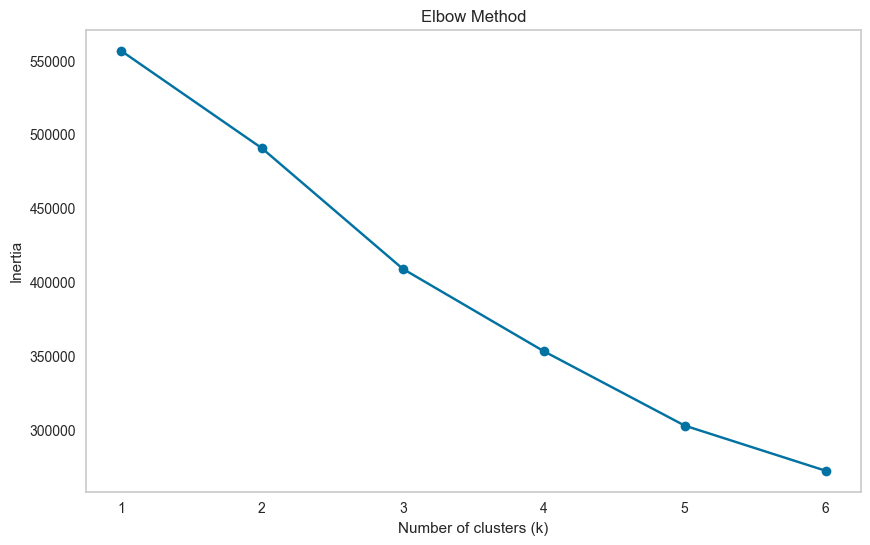

In [26]:
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# Sélectionner les caractéristiques pour le clustering
features = df_no_outliers[['recence', 'frequence', 'montant', 'review_score', 'approval_delay_days', 'processing_delay_days']]

# Imputer les valeurs manquantes avec la moyenne
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
features_imputed = imputer.fit_transform(features)

# Normaliser les données
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_imputed)

# Calculer l'inertie pour différentes valeurs de k
inertias = []
k_values = range(1, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)

# Tracer la méthode du coude
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid()
plt.show()

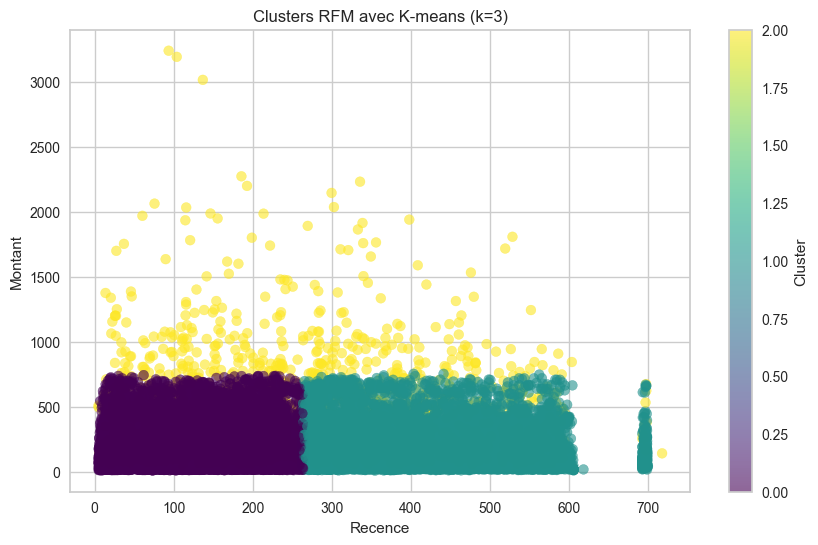

In [28]:
# Tracer les clusters
plt.figure(figsize=(10, 6))
plt.scatter(df_no_outliers['recence'], df_no_outliers['montant'], c=df_no_outliers['cluster'], cmap='viridis', s=50, alpha=0.6)
plt.xlabel('Recence')
plt.ylabel('Montant')
plt.title('Clusters RFM avec K-means (k=3)')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
# Obtenir les centroïdes
centroids = kmeans.cluster_centers_

# Convertir les centroïdes en df_no_outliersFrame pour une meilleure visualisation
centroids_df = pd.DataFrame(centroids, columns=['recence', 'frequence', 'montant', 'review_score', 'approval_delay_days', 'processing_delay_days'])

# Afficher les centroïdes
print(centroids_df)

    recence  frequence   montant  review_score  approval_delay_days  \
0 -0.762693  -0.165758 -0.258592      0.378954            -0.203579   
1  1.004748  -0.150653 -0.246110      0.341996            -0.174197   
2 -0.012824   4.908334  1.675490     -0.549536             0.027523   
3 -0.029331  -0.000910 -0.056680     -1.981136            -0.128405   
4 -0.040868  -0.113551 -0.155353      0.072638             3.471387   
5 -0.010197   0.089240  2.340999      0.175877            -0.119986   

   processing_delay_days  
0              -0.291907  
1              -0.111504  
2              -0.104075  
3               1.112469  
4               0.152509  
5               0.009488  


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Assurez-vous que la colonne de date est au format datetime
df_no_outliers['order_purchase_timestamp'] = pd.to_datetime(df_no_outliers['order_purchase_timestamp'])

# Créer une colonne pour identifier les périodes de trois mois
df_no_outliers['period'] = df_no_outliers['order_purchase_timestamp'].dt.to_period('3M')

# Sélectionner les caractéristiques pour le clustering
features = ['recence', 'frequence', 'montant', 'review_score', 'approval_delay_days', 'processing_delay_days']

# Remplacer les valeurs manquantes par la moyenne de chaque colonne
df_no_outliers[features] = df_no_outliers[features].fillna(df_no_outliers[features].mean())

# Fonction pour appliquer K-Means et obtenir les clusters
def apply_kmeans(data, n_clusters=3):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    return kmeans.fit_predict(data_scaled)


# Filtrer les périodes avec suffisamment de données
periods = df_no_outliers['period'].value_counts()[df_no_outliers['period'].value_counts() >= 3].index

# Appliquer K-Means pour chaque période de trois mois
clusters_periods = {}

for period in periods:
    period_data = df_no_outliers[df_no_outliers['period'] == period]
    if len(period_data) > 0:  # Vérifier s'il y a des données pour cette période
        clusters = apply_kmeans(period_data[features])
        clusters_periods[period] = clusters

# Ajouter les clusters au DataFrame
for period in clusters_periods:
    df_no_outliers.loc[df_no_outliers['period'] == period, 'Cluster'] = clusters_periods[period]

# Afficher les résultats
display(df_no_outliers)


,recence,frequence,price,freight_value,montant,review_score,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,approval_delay_minutes,approval_delay_hours,approval_delay_days,processing_delay_hours,processing_delay_days,cluster,period,Cluster
0,320.833657,22,69.90,33.72,1707.88,1,2017-10-17 13:06:29,2017-10-18 13:06:21,2017-10-22 14:43:54,1439.866667,23.997778,0.0,121.623611,5.0,2,2017-10,2.0
1,413.616343,21,1.20,7.89,196.17,1,2017-07-16 18:19:25,2017-07-17 18:25:23,2017-07-31 18:03:02,1445.966667,24.099444,1.0,359.726944,14.0,2,2017-07,2.0
2,192.733519,20,100.00,10.12,2202.40,1,2018-02-22 15:30:41,2018-02-24 03:20:27,2018-03-05 15:22:27,2149.766667,35.829444,1.0,263.862778,10.0,2,2018-02,2.0
3,580.473704,15,51.00,1.20,783.00,5,2017-01-30 21:44:49,2017-01-30 22:33:45,2017-02-14 10:48:10,48.933333,0.815556,0.0,349.055833,14.0,2,2017-01,2.0
4,283.525058,15,65.49,16.22,1225.65,5,2017-11-23 20:30:52,2017-11-24 10:31:10,2017-12-13 20:19:35,840.300000,14.005000,0.0,479.811944,19.0,2,2017-11,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95827,153.808796,1,93.00,14.01,107.01,4,2018-04-02 13:42:17,2018-04-04 03:10:19,2018-04-13 20:21:08,2248.033333,37.467222,1.0,270.647500,11.0,0,2018-04,1.0
95828,382.831678,1,149.90,29.45,179.35,5,2017-08-16 13:09:20,2017-08-17 03:10:27,2017-09-13 20:06:02,841.116667,14.018611,0.0,678.945000,28.0,1,2017-08,0.0
95829,551.916829,1,179.99,15.43,195.42,5,2017-02-28 11:06:43,2017-02-28 11:15:20,2017-03-06 08:57:49,8.616667,0.143611,0.0,141.851667,5.0,1,2017-02,1.0
95830,413.976678,1,54.90,12.51,67.41,4,2017-07-16 09:40:32,2017-07-16 09:55:12,2017-07-25 18:57:33,14.666667,0.244444,0.0,225.283611,9.0,1,2017-07,1.0


In [64]:
from sklearn.metrics import adjusted_rand_score

# Calculer l'ARI entre les clusters de chaque période et la période initiale
reference_period = periods[0]
reference_clusters = clusters_periods[reference_period]

ari_scores = []
for period in periods[1:]:
    ari = adjusted_rand_score(reference_clusters, clusters_periods[period])
    ari_scores.append((period, ari))

# Afficher les scores ARI
for period, ari in ari_scores:
    print(f'Période {period}: ARI = {ari:.2f}')



ValueError: Found input variables with inconsistent numbers of samples: [7030, 6835]

In [50]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

# Prétraitement des données
df_no_outliers['order_purchase_timestamp'] = pd.to_datetime(df_no_outliers['order_purchase_timestamp'])
df_no_outliers['recence'] = df_no_outliers['recence'].fillna(df_no_outliers['recence'].mean())
df_no_outliers['review_score'] = df_no_outliers['review_score'].fillna(df_no_outliers['review_score'].mean())

# Segmenter les données par période de 3 mois
df_no_outliers['period'] = df_no_outliers['order_purchase_timestamp'].dt.to_period('6M')

# Fonction pour appliquer K-Means et obtenir les clusters
def apply_kmeans(data, n_clusters=3):
    if len(data) < n_clusters:
        return None  # Retourner None si pas assez de données
    features = data[['recence', 'frequence', 'montant']]
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    return kmeans.fit_predict(features_scaled)

# Filtrer les périodes avec suffisamment de données
periods = df_no_outliers['period'].value_counts()[df_no_outliers['period'].value_counts() >= 3].index

# Appliquer K-Means pour chaque période et stocker les clusters
clusters_periods = []
for period in periods:
    print(f"Period={period}")
    clusters = apply_kmeans(df_no_outliers[df_no_outliers['period'] == period])
    if clusters is not None:
        clusters_periods.append(clusters)
    print(clusters)

display(periods)

# Vérifiez que tous les clusters ont la même longueur
# if len(set(len(clusters) for clusters in clusters_periods)) != 1:
#     raise ValueError("Les clusters n'ont pas tous la même longueur.")

# Calculer l'ARI entre les clusters de chaque période et la période initiale
ari_scores = [adjusted_rand_score(clusters_periods[0], clusters) for clusters in clusters_periods]

# Afficher les scores ARI
print(ari_scores)


Period=2017-11
[2 2 2 ... 0 1 1]
Period=2018-01
[2 2 2 ... 1 1 1]
Period=2018-03
[2 2 2 ... 0 0 0]
Period=2018-04
[2 2 2 ... 0 1 0]
Period=2018-05
[2 2 2 ... 0 0 0]
Period=2018-02
[2 2 2 ... 0 1 0]
Period=2018-08
[2 2 2 ... 1 1 0]
Period=2018-07
[2 2 2 ... 0 0 1]
Period=2018-06
[2 2 2 ... 1 1 0]
Period=2017-12
[2 2 2 ... 1 1 1]
Period=2017-10
[2 2 2 ... 1 1 1]
Period=2017-08
[2 2 2 ... 1 0 1]
Period=2017-09
[2 2 2 ... 0 1 0]
Period=2017-07
[2 2 2 ... 1 0 1]
Period=2017-05
[2 2 2 ... 1 1 1]
Period=2017-06
[2 2 2 ... 0 0 0]
Period=2017-03
[2 2 2 ... 1 0 0]
Period=2017-04
[2 2 2 ... 0 0 1]
Period=2017-02
[2 2 2 ... 0 0 0]
Period=2017-01
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 0 2 2 2 1 2 0 0 0 0 0 2 0
 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 2 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 1 0 0 0 1 0 1 0 0 0 1 1 0 1 0 0 0 1 1 1 1 0 1 0 0 0 1 1 0 0 1 1 1 0 0
 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1
 0 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0

PeriodIndex(['2017-11', '2018-01', '2018-03', '2018-04', '2018-05', '2018-02',
             '2018-08', '2018-07', '2018-06', '2017-12', '2017-10', '2017-08',
             '2017-09', '2017-07', '2017-05', '2017-06', '2017-03', '2017-04',
             '2017-02', '2017-01', '2016-10'],
            dtype='period[6M]', name='period')

ValueError: Found input variables with inconsistent numbers of samples: [7030, 6835]

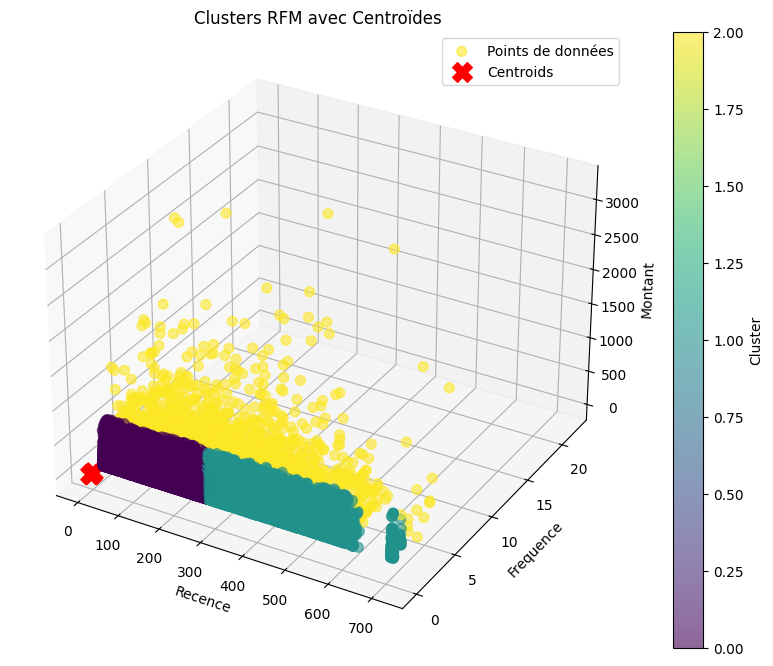

In [98]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

# Supposons que rfm_scored est votre DataFrame et que vous avez déjà calculé les clusters
# features_scaled est votre ensemble de données normalisées
# kmeans est votre modèle KMeans ajusté

# Tracer les points de données
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Tracer les points de données colorés par cluster
scatter = ax.scatter(
    df_no_outliers['recence'],
    df_no_outliers['frequence'],
    df_no_outliers['montant'],
    c=df_no_outliers['cluster'],
    cmap='viridis',
    s=50,
    alpha=0.6,
    label='Points de données'
)

# Tracer les centroïdes
centroids = kmeans.cluster_centers_
ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    centroids[:, 2],
    c='red',
    s=200,
    alpha=1,
    marker='X',
    label='Centroids'
)

# Ajouter des labels et un titre
ax.set_xlabel('Recence')
ax.set_ylabel('Frequence')
ax.set_zlabel('Montant')
ax.set_title('Clusters RFM avec Centroïdes')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.legend()
plt.show()
